In [1]:
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import openpyxl
from datetime import datetime

In [2]:
!pip install openpyxl

In [3]:
log_name = '/Users/jmanasse/Desktop/stanford/2025-2026/staar_lab_code/video_data/aggression_data/20251117/logs/20251117_PJA122_intruder3_day14_withphotostim20251117_14_58_11_time_log.csv'
true_attacks = '/Users/jmanasse/Desktop/stanford/2025-2026/staar_lab_code/true_attacks_1117_122_3.xlsx'

In [6]:
logs = pd.read_csv(log_name)
attacks = pd.read_excel(true_attacks, engine='openpyxl')

In [7]:
attacks.head()
starts = list(attacks['start'])
ends = list(attacks['end'])
date_format = '%Y-%m-%d_%H:%M:%S.%f'
starts = [datetime.strptime(start_time.replace(" ", ""),date_format) for start_time in starts]
ends = [datetime.strptime(end_time.replace(" ", ""),date_format) for end_time in ends]

In [53]:

light_on_times = list(logs['start_times'])
light_off_times = list(logs['end_times'])
light_on_times = [datetime.strptime(light_on_time.replace(" ", ""),date_format) for light_on_time in light_on_times]
light_off_times = [datetime.strptime(light_off_time.replace(" ", ""),date_format) for light_off_time in light_off_times]
logs.head()

,Unnamed: 0,start_times,attack_stop_times,end_times,on_status
0,0,2025-11-17_15:00:56.381023,2025-11-17_15:00:57.960058,2025-11-17_15:01:06.394152,True
1,1,2025-11-17_15:01:40.910416,2025-11-17_15:01:44.160305,2025-11-17_15:01:50.926685,False
2,2,2025-11-17_15:02:40.298163,2025-11-17_15:02:46.535841,2025-11-17_15:02:50.327545,False
3,3,2025-11-17_15:03:00.877841,2025-11-17_15:03:01.834325,2025-11-17_15:03:10.882887,True
4,4,2025-11-17_15:04:02.785346,2025-11-17_15:04:04.031725,2025-11-17_15:04:12.796866,False


In [79]:
attack_stop_times = list(logs['attack_stop_times'])
attack_stop_times = [datetime.strptime(attack_stop_time.replace(" ", ""),date_format) for attack_stop_time in attack_stop_times]

3.377516
0.754665
1.139603
0.572834
0.949955
1.128994
2.222252
4.134495
1.620987
1.7668112222222223 1.1712511824574396


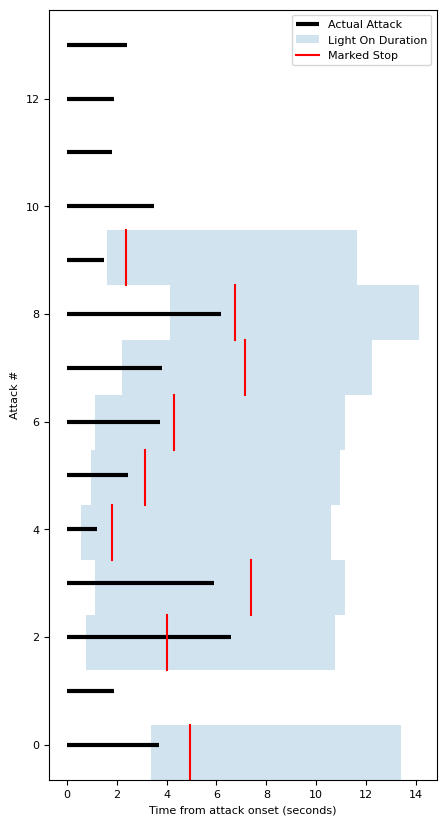

In [89]:

# Sample data: event times and corresponding line lengths
event_times = [0]*14
line_lengths = [(end-start).total_seconds() for end, start in zip(ends,starts)] # Variable lengths
trials = list(range(len(starts)))

# Create the figure and axes
fig, ax = plt.subplots(figsize=(5, 10))

# Plot each event as a vertical line with its specified length
epsilon = 5.0
diff = []
for trial in trials:
    ax.hlines(y=trial, xmin=event_times[trial], xmax=line_lengths[trial], color='black', linewidth=3)
    for i in range(10):
        if abs((light_on_times[i] - starts[trial]).total_seconds()) < epsilon:
            print((light_on_times[i] - starts[trial]).total_seconds())
            # ax.fill_betweenx(y=trial,x1=(light_on_times[i] - starts[trial]).total_seconds(), x2=(light_off_times[i] - starts[trial]).total_seconds(), color='blue', alpha=0.3)
            ax.axvspan((light_on_times[i] - starts[trial]).total_seconds(), (light_off_times[i] - starts[trial]).total_seconds(), ymin=(trial/14), ymax=((trial+1)/14), alpha=0.2)
            ax.axvline(x=(attack_stop_times[i] - starts[trial]).total_seconds(),color='red',ymin=(trial/14), ymax=((trial+1)/14))
            diff.append((light_on_times[i] - starts[trial]).total_seconds())
# Set plot limits and labels
# ax.set_xlim(0, 5)
# ax.set_ylim(0, 1)
ax.legend(['Actual Attack','Light On Duration','Marked Stop'], loc='upper right')
ax.set_xlabel("Time from attack onset (seconds)")
ax.set_ylabel("Attack #")
# ax.set_title("Raster Plot with Variable Line Lengths")
print(np.mean(diff), np.std(diff))
# # Display the plot
# plt.show()

In [43]:

len(starts)

14